In [2]:
# !unzip myds.zip

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageFile
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from sklearn.model_selection import train_test_split

## Dataset

In [39]:
myds_path = Path("myds/")

label_map = {
  "aegypti": 0,
  "albopictus": 1,
  "anopheles": 2,
  "culex": 3,
  "culiseta": 4,
  "japonicus/koreicus": 5,
  "None": 6,
}
inv_label_map = {v: k for k, v in label_map.items()}

In [5]:
def load_label(label_path: Path) -> list[tuple]:
  bboxes = []
  with open(label_path, "r") as f:
    for l in f.readlines():
      data = l.split()
      klass = label_map[data[0]]
      xc, yc, w, h = map(float, data[1:])
      bboxes.append((klass, xc, yc, w, h))
  return bboxes


def label_to_xyxy(bboxes: tuple, image: ImageFile.ImageFile) -> tuple[torch.Tensor, torch.Tensor]:
  img_w, img_h = image.size
  tbboxes = []
  tklasses = []
  for bbox in bboxes:
    klass, xc, yc, w, h = bbox
    x1 = (xc - w / 2) * img_w
    y1 = (yc - h / 2) * img_h
    x2 = (xc + w / 2) * img_w
    y2 = (yc + h / 2) * img_h
    tbboxes.append([x1,y1,x2,y2])
    tklasses.append(int(klass))
  return torch.tensor(tklasses), torch.tensor(tbboxes)


def get_images_and_labels_paths(root: Path, train: bool) -> tuple[list[Path], list[Path]]:
    if train:
      image_paths = list((root / "train" / "images").glob("*_orig.jpg"))
      label_paths = [root / "train" / "labels" / (p.stem + ".txt") for p in image_paths]
    else:
      image_paths = list((root / "test" / "images").glob("*.jpeg"))
      label_paths = None
    return image_paths, label_paths


class MyDataset(Dataset):
  def __init__(self, image_paths, label_paths, indices: list[int]):
    self.indices = indices
    self.image_paths, self.label_paths = image_paths, label_paths

  def __len__(self):
    return len(self.indices)

  def __getitem__(self, idx) -> tuple[ImageFile.ImageFile, dict | None]:
    image_path = self.image_paths[self.indices[idx]]
    image = Image.open(image_path)
    if self.label_paths:
      label_path = self.label_paths[self.indices[idx]]
      label = load_label(label_path)
      klasses, bboxes = label_to_xyxy(label, image)
      label = {}
      label["labels"] = klasses
      label["boxes"] = bboxes
    else:
      label = None

    return T.ToTensor()(image), label

In [6]:
train_images, train_labels = get_images_and_labels_paths(myds_path, True)
test_images, test_labels = get_images_and_labels_paths(myds_path, False)

train_inds, val_inds = train_test_split(range(len(train_images)), test_size=0.2)

train_ds = MyDataset(train_images, train_labels, train_inds)
val_ds = MyDataset(train_images, train_labels, val_inds)
test_ds = MyDataset(test_images, test_labels, list(range(len(test_images))))

train_dl = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=lambda x: x)
val_dl = DataLoader(val_ds, batch_size=8, shuffle=True, collate_fn=lambda x: x)
test_dl = DataLoader(test_ds, batch_size=8, shuffle=False, collate_fn=lambda x: x)

In [7]:
def plot_image_with_bbox(image, target):
  image = image.permute(1, 2, 0).cpu().numpy()

  fig, ax = plt.subplots(1)
  ax.imshow(image)

  for box, label in zip(target['boxes'], target['labels']):
    x1, y1, x2, y2 = box
    class_name = list(label_map.keys())[list(label_map.values()).index(label.item())]
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1, class_name, color='r')

  ax.set_axis_off()
  plt.show()

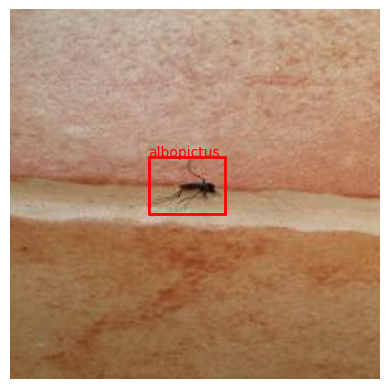

In [8]:
image, target = train_ds[0]
plot_image_with_bbox(image, target)

## Model

In [9]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True, trainable_backbone_layers=0)
num_classes = len(label_map)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 150MB/s]


In [10]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [9]:
# optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
# num_epochs = 10

In [10]:
# model.train()
# model.to(device)

# losses = []
# for epoch in range(num_epochs):
#   epoch_loss = 0
#   for data in train_dl:
#     imgs = []
#     targets = []
#     for d in data:
#       imgs.append(d[0].to(device))
#       targ = {}
#       targ["boxes"] = d[1]["boxes"].to(device)
#       targ["labels"] = d[1]["labels"].to(device)
#       targets.append(targ)
#     loss_dict = model(imgs, targets)
#     loss = sum(v for v in loss_dict.values())
#     epoch_loss += loss.cpu().detach().numpy()
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()
#   losses.append(epoch_loss)
#   print(epoch, epoch_loss)

0 146.86313094198704
1 120.15440768003464
2 112.82379410415888
3 106.70049472898245
4 103.64163326472044


KeyboardInterrupt: 

In [12]:
# torch.save(model, "model.pth")
# print(losses)

[146.86313094198704, 120.15440768003464, 112.82379410415888, 106.70049472898245, 103.64163326472044]


In [13]:
model = torch.load("model.pth");

<ipython-input-13-92534b9dfbf5>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("model.pth");


In [14]:
def plot_image_with_bbox(image, prediction):
  image = image.cpu().numpy().transpose(1, 2, 0)

  fig, ax = plt.subplots(1)
  ax.imshow(image)

  for box, label, score in zip(prediction['boxes'], prediction['labels'], prediction['scores']):
    box, label, score = box.cpu().numpy(), label.cpu().numpy(), score.cpu().numpy()
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    class_name = list(label_map.keys())[list(label_map.values()).index(label.item())]
    ax.text(x1, y2, f'{class_name}: {score:.2f}', color='r')
    break

  ax.set_axis_off()
  plt.show()

In [15]:
model.eval()
model.to(device)
with torch.no_grad():
    for data in test_dl:
        images = data[1][0].to(device)
        predictions = model([images])
        break

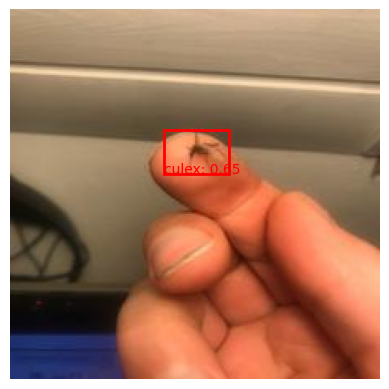

In [16]:
plot_image_with_bbox(images, predictions[0])

In [42]:
model.eval()
model.to(device)

all_predictions = []

with torch.no_grad():
    for data in test_dl:
        imgs = []
        targets = []
        for d in data:
          imgs.append(d[0].to(device))
        predictions = model(imgs)
        for pred in predictions:
          x1,y1,x2,y2 = pred["boxes"][0].cpu().numpy()
          res = {
              "LabelName": inv_label_map[int(pred["labels"][0].cpu().numpy())],
              "Conf": float(pred["scores"][0].cpu().numpy()),
              "xcenter": float((x1+x2)/2) / 224,
              "ycenter": float((y1+y2)/2) / 224,
              "bbx_width": float(x2-x1) / 224,
              "bbx_height": float(y2-y1) / 224,
          }
          all_predictions.append(res)

In [47]:
subm = pd.DataFrame(all_predictions)
subm.insert(0, "ImageID", [p.name for p in test_images])
subm.head(2)

,ImageID,LabelName,Conf,xcenter,ycenter,bbx_width,bbx_height
0,3d7179d9-2959-4586-9a2e-5b67b087ff05.jpeg,culex,0.899718,0.375569,0.643268,0.329655,0.283349
1,063c9e1d-cd3c-4c8b-9feb-75ef44904d59.jpeg,culex,0.652300,0.501639,0.383488,0.177106,0.117398


In [46]:
sample_subm = pd.read_csv('sample_submission.csv')[["id", "ImageID"]]
sample_subm.head(2)

,id,ImageID
0,0,16dbbc39-fcb6-498e-963f-d3807fcc3cec.jpeg
1,1,7daa68bd-928b-4b43-850f-4626f16d2c14.jpeg


In [49]:
sample_subm.merge(subm, on="ImageID").to_csv("submission.csv", index=False)